In [12]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

ages_myr_1 = np.arange(0,100,10)
ages_myr_2 = np.arange(200, 1000, 100)

ages_gyr = np.concatenate([ages_myr_1, ages_myr_2]) / 1000

In [15]:
dust = {}
dust["type"] = "Calzetti"
dust["Av"] = 0.2

base = (
    r"D:/Users/Abigail Crowther/Desktop/Uni/Year 4/MPhys Projects/"
    r"Semester 2 - Star Formation Histories/star-formation-histories/bagpipes/examples"
)

rel_filters = np.loadtxt(base + "/filters/goodss_filt_list.txt", dtype="str")
goodss_filt_list = [base + "/" + f for f in rel_filters]

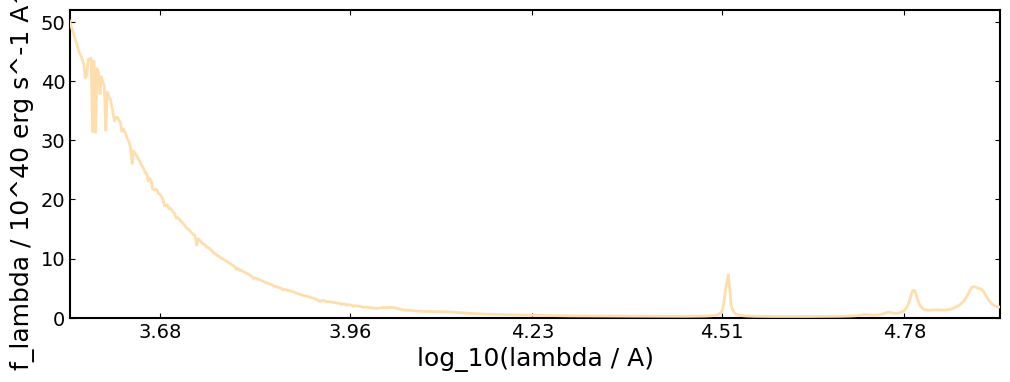

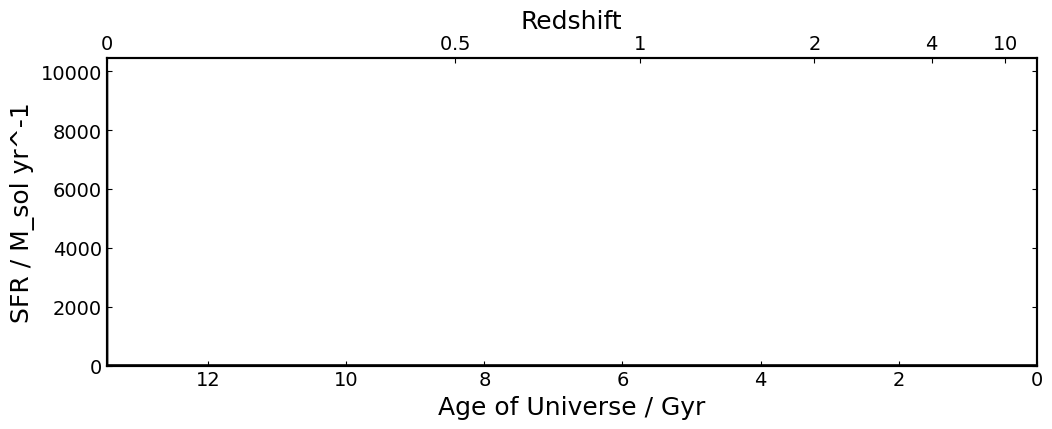

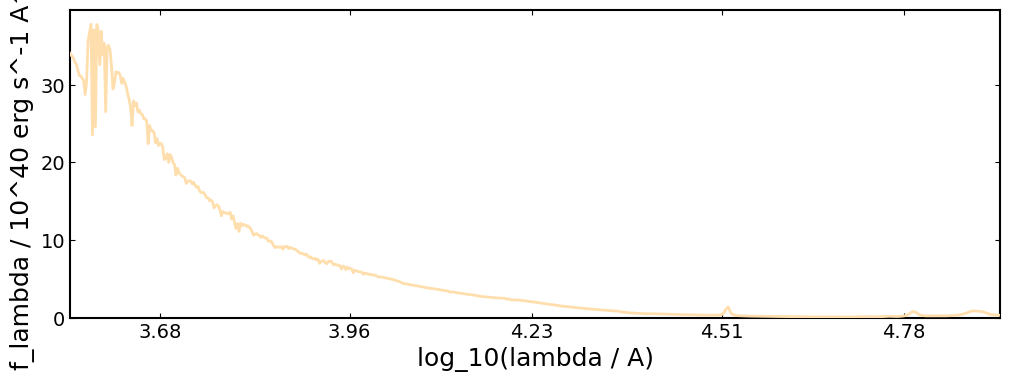

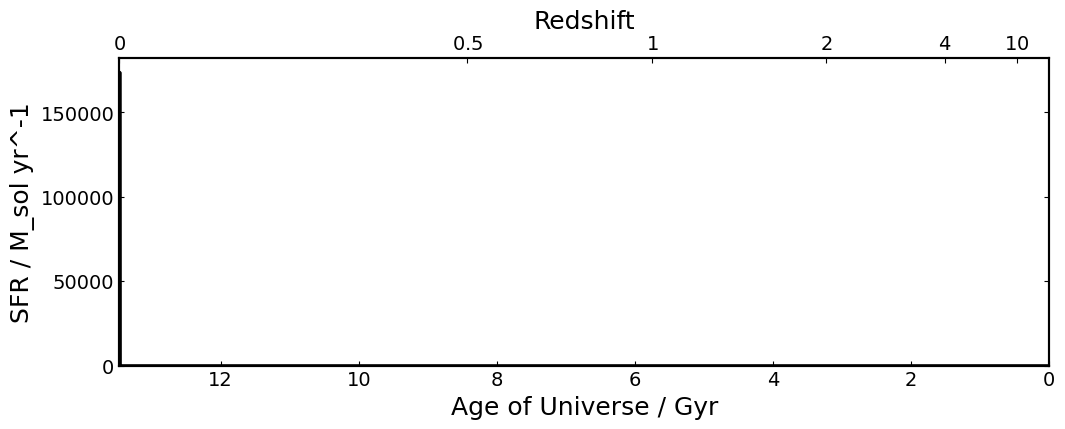

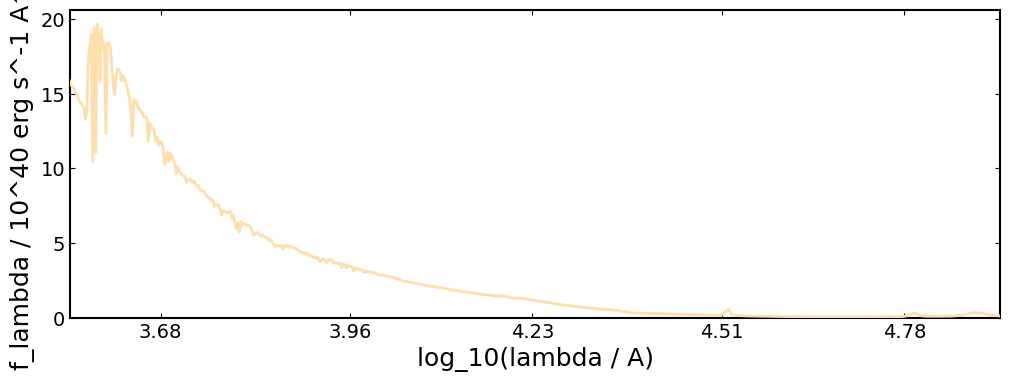

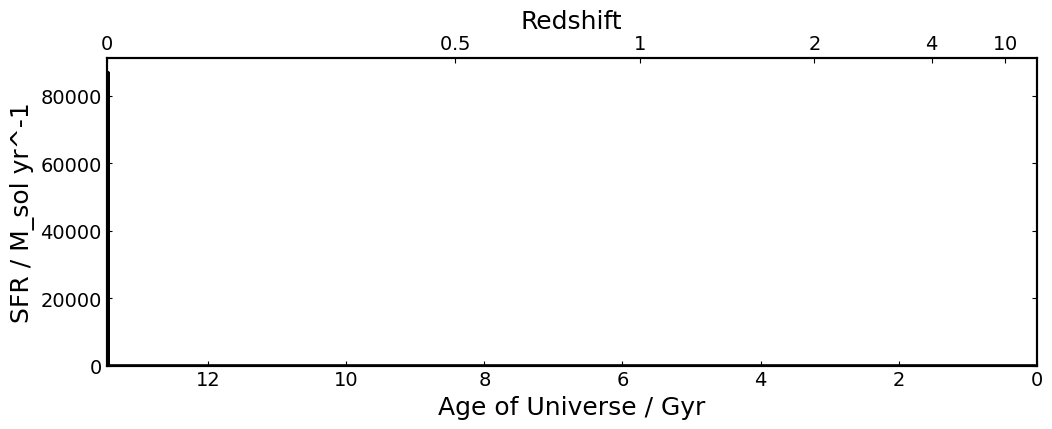

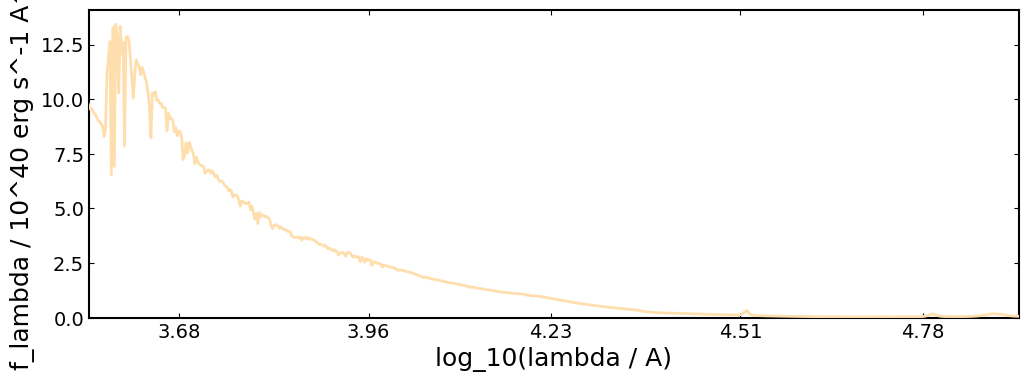

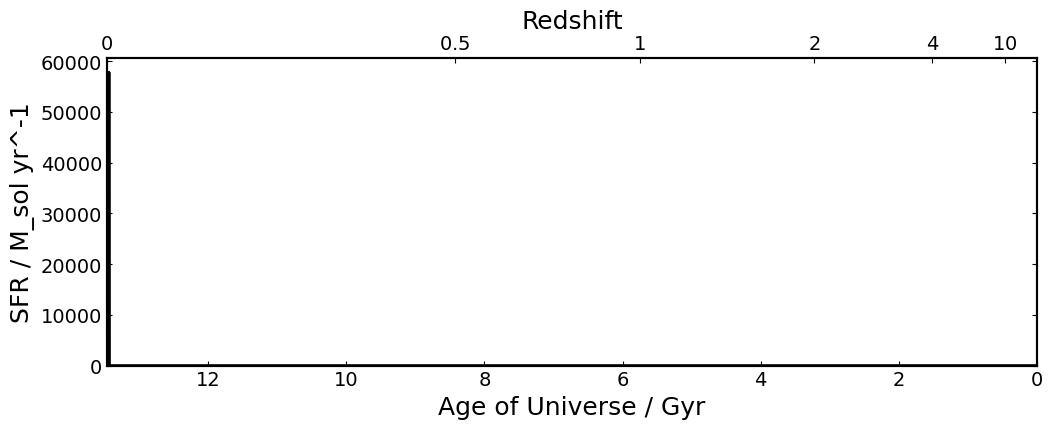

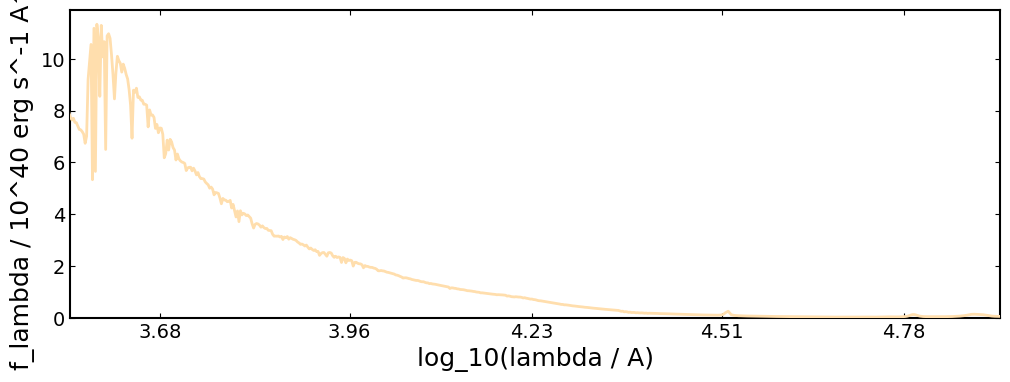

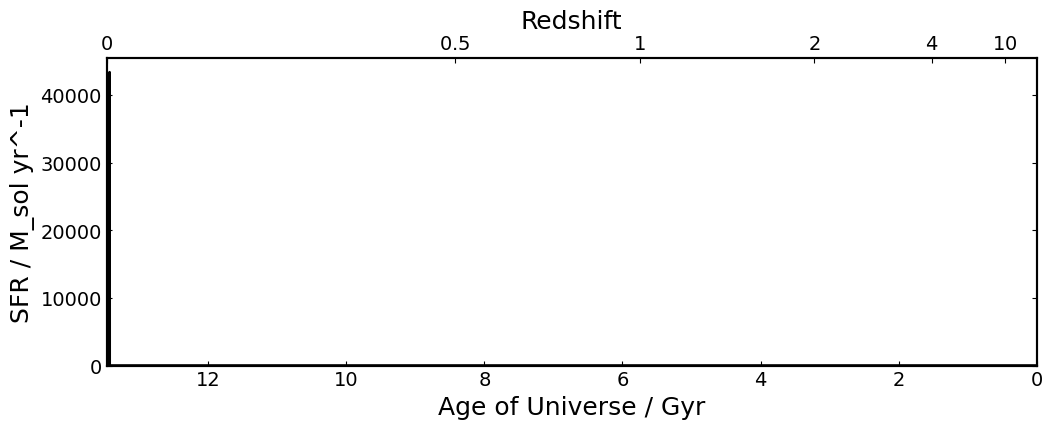

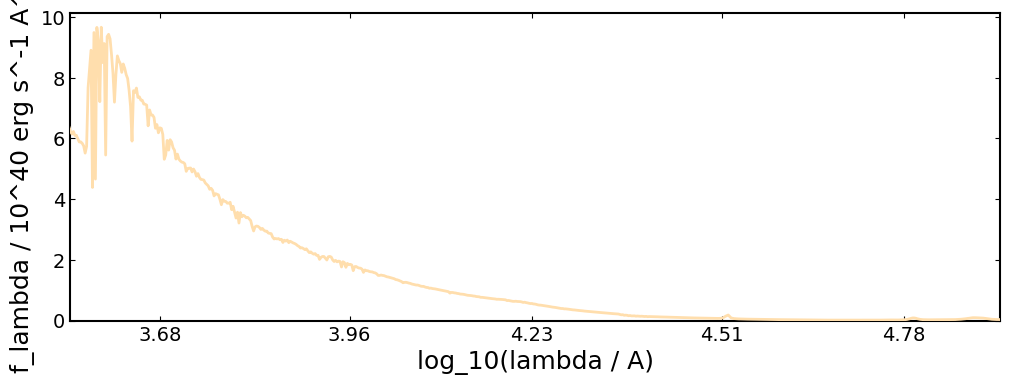

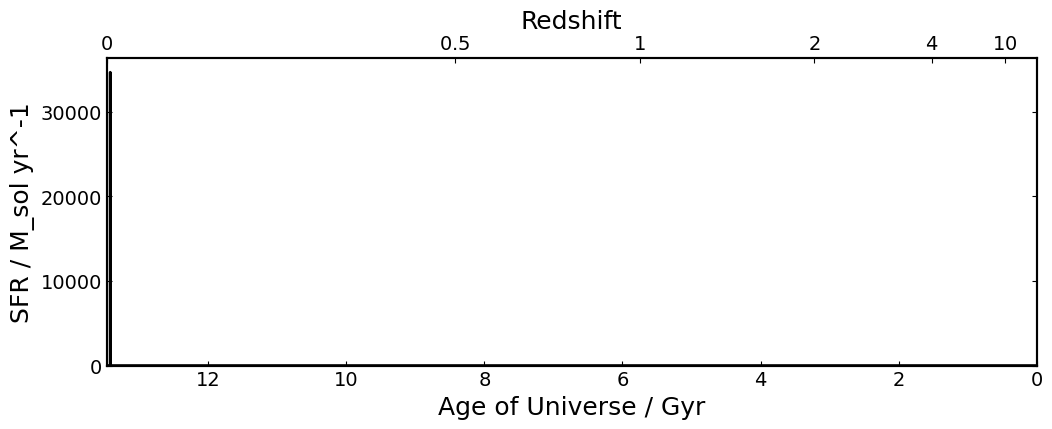

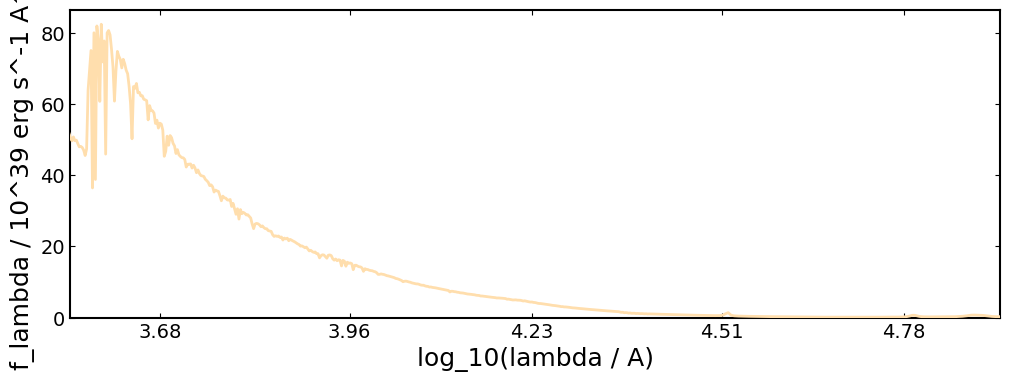

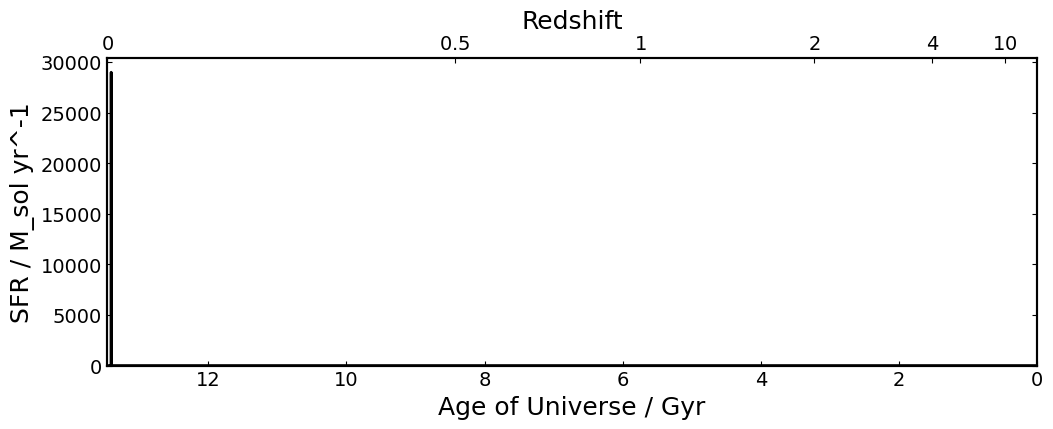

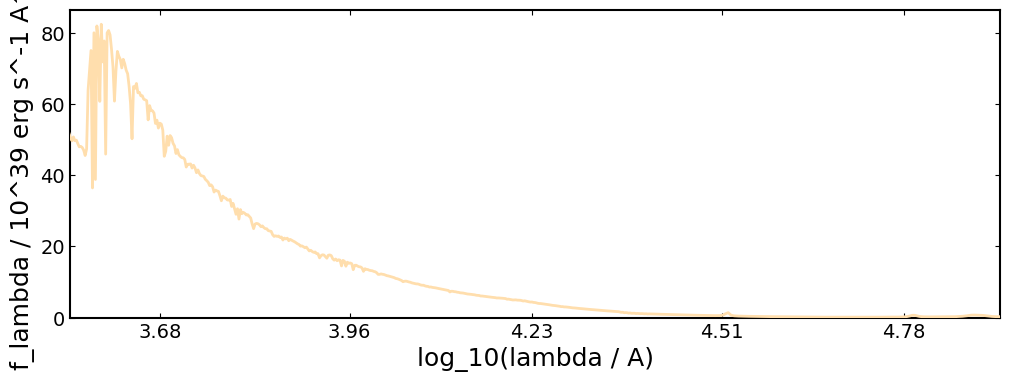

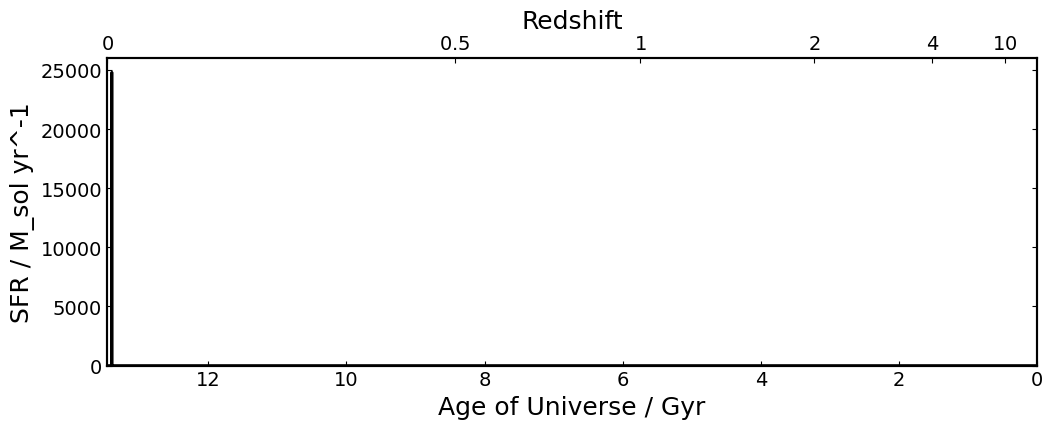

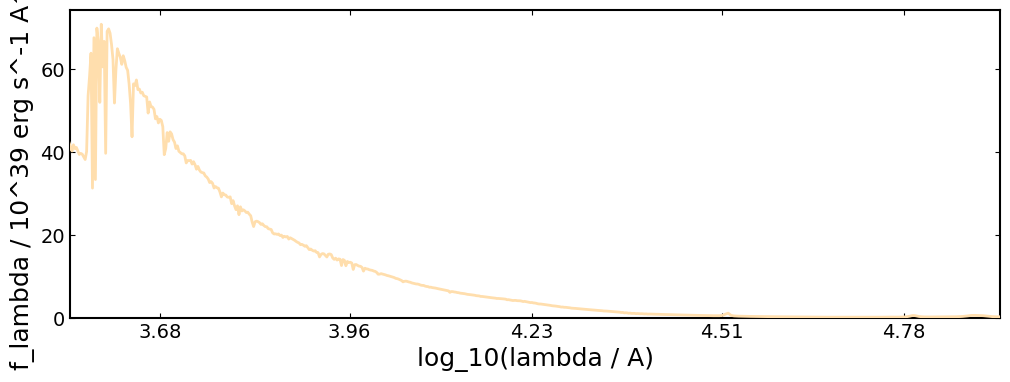

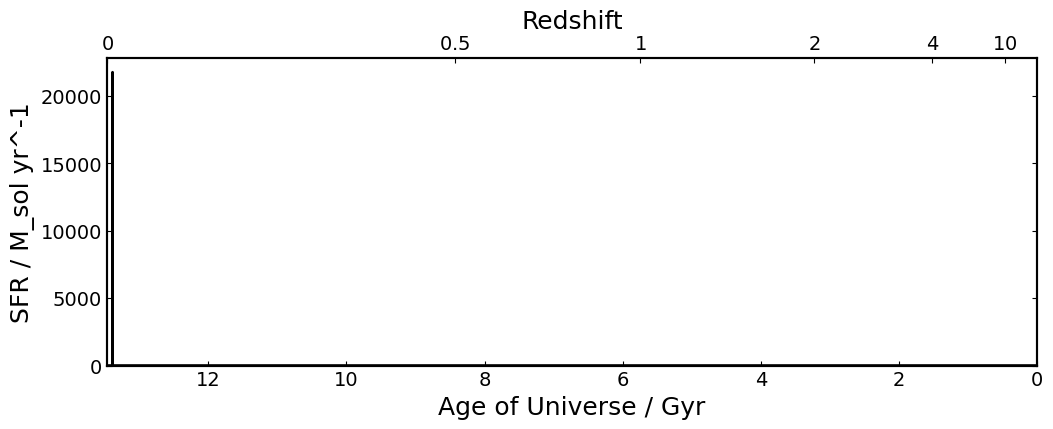

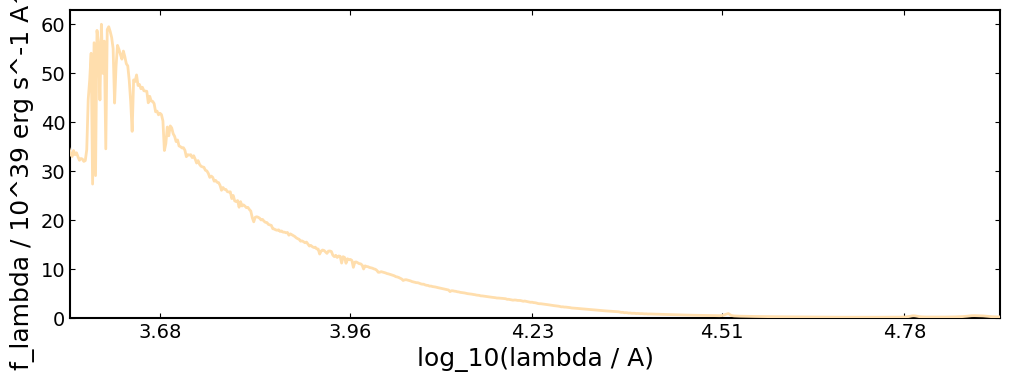

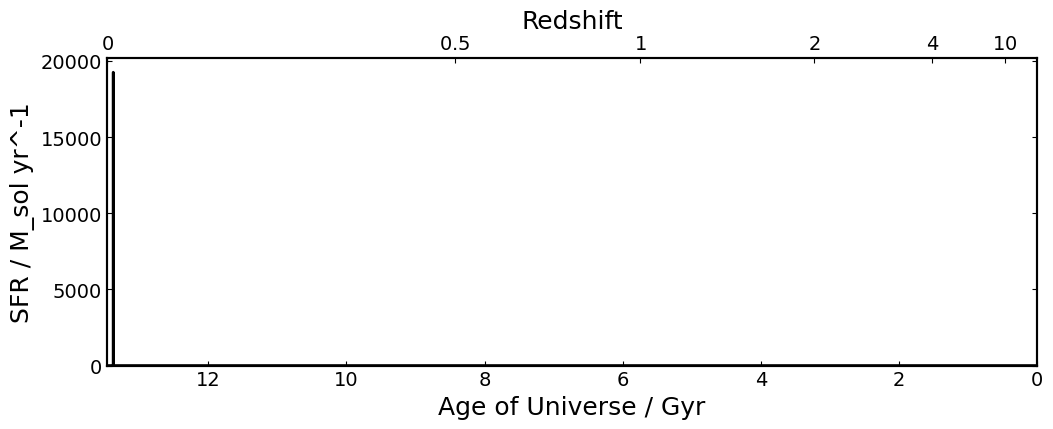

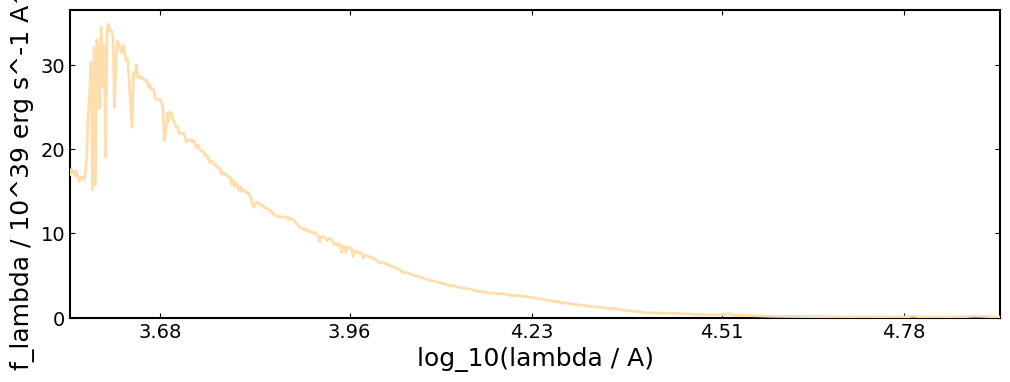

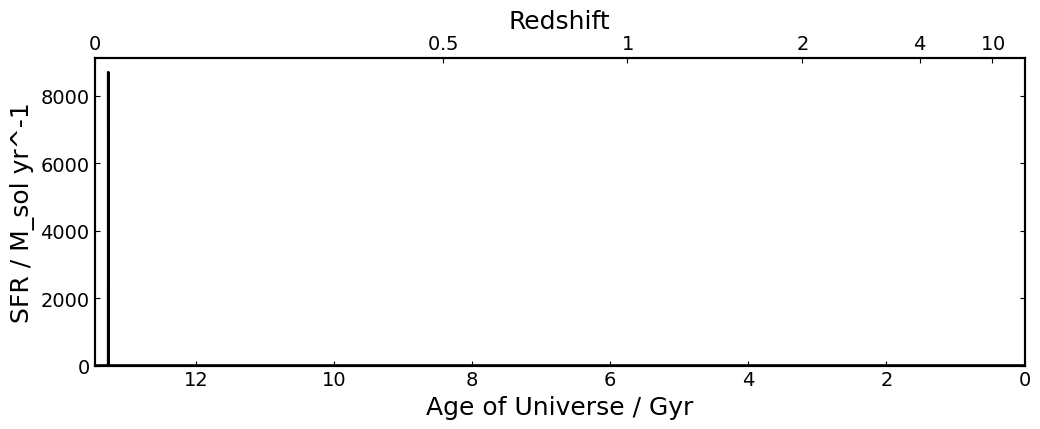

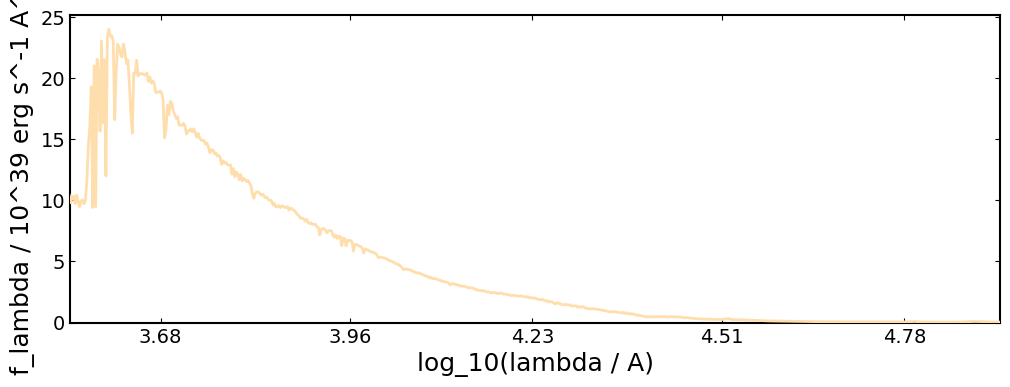

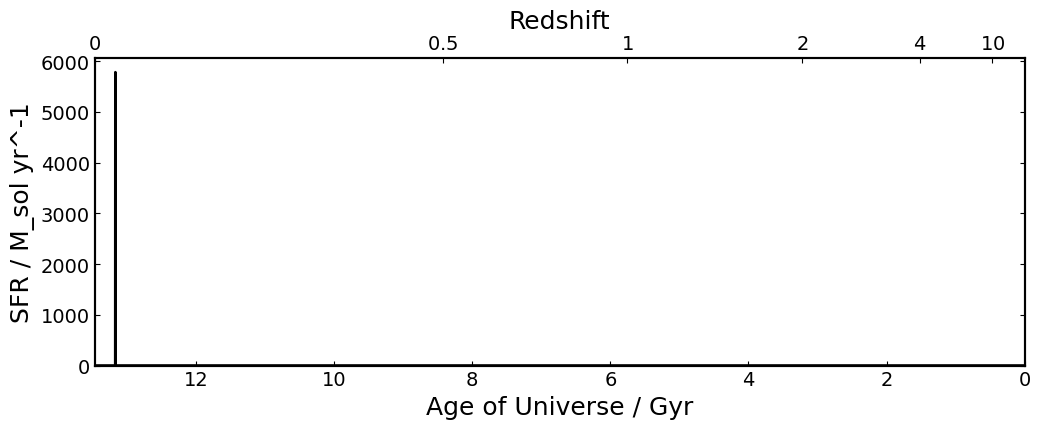

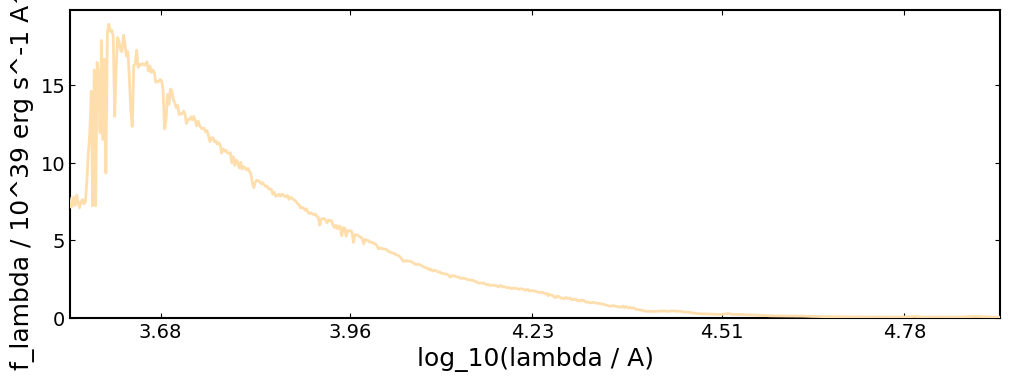

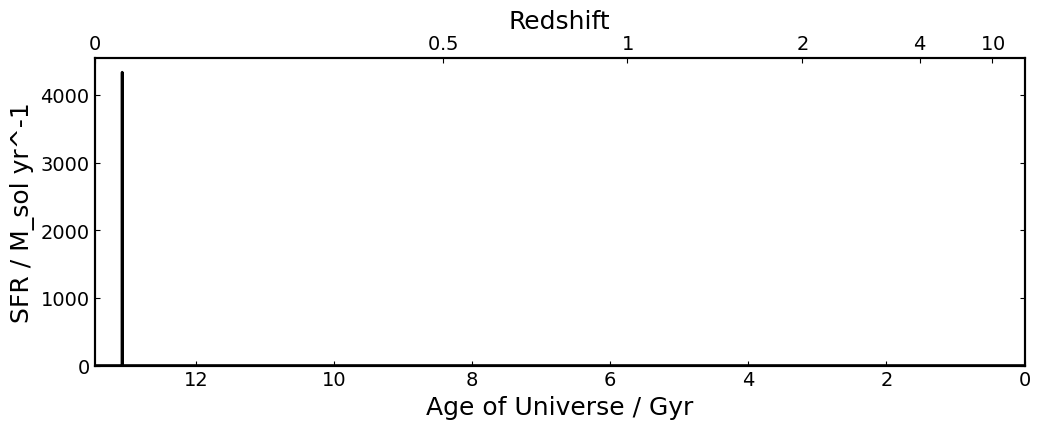

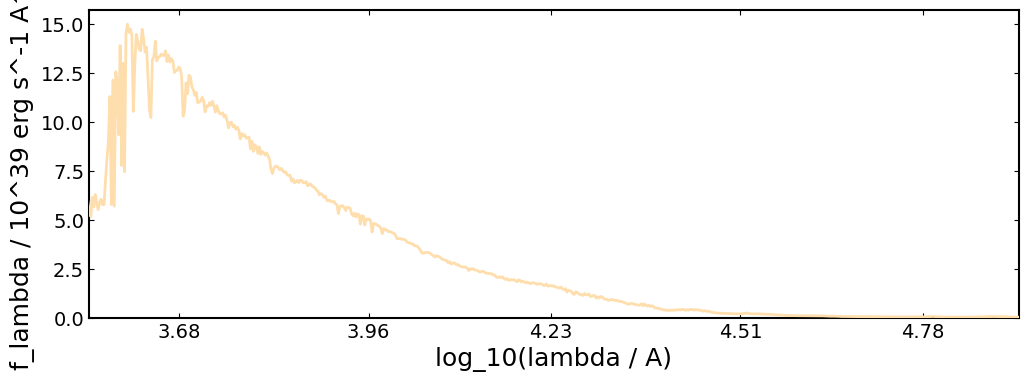

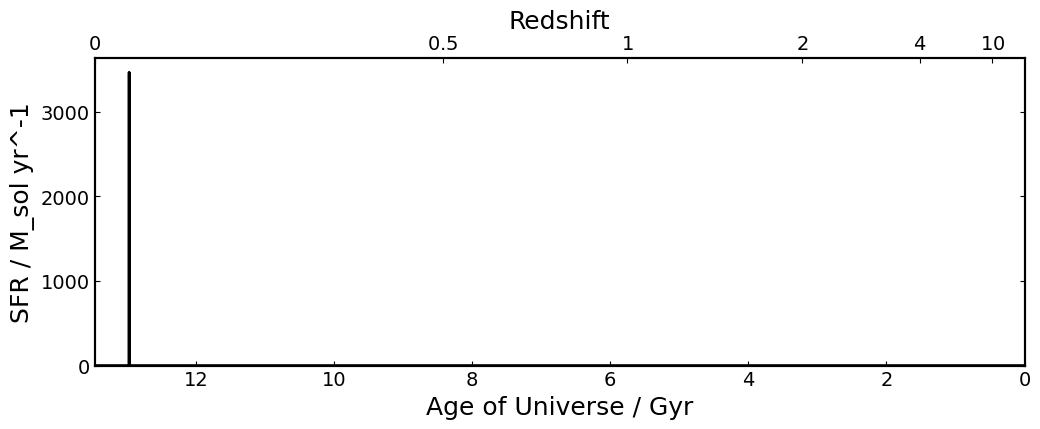

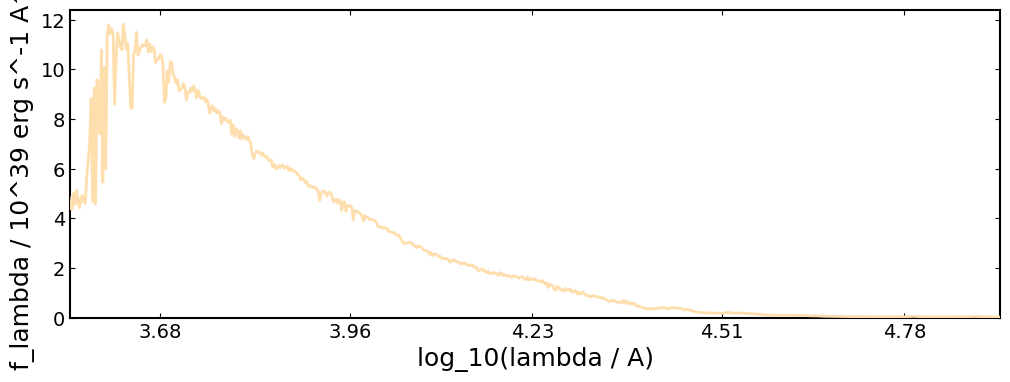

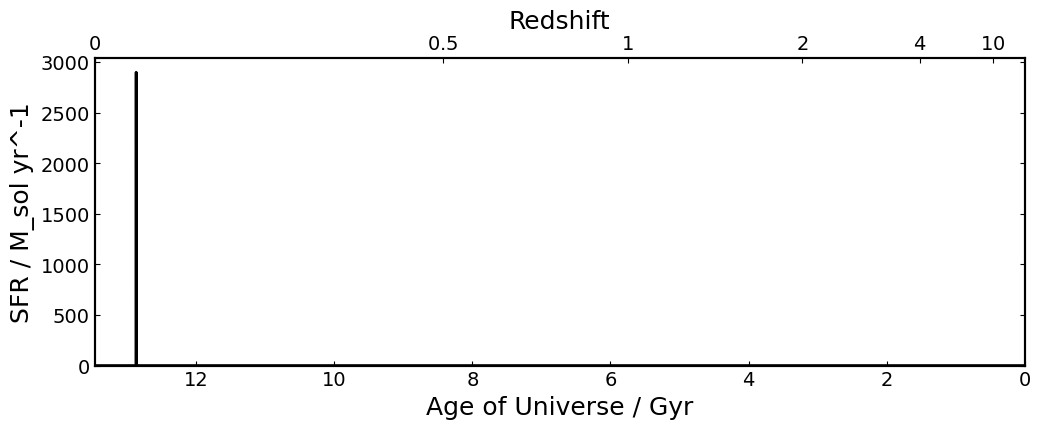

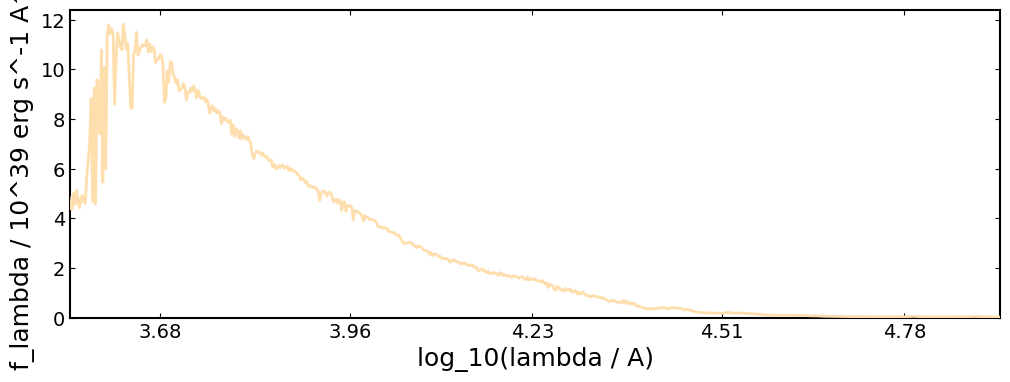

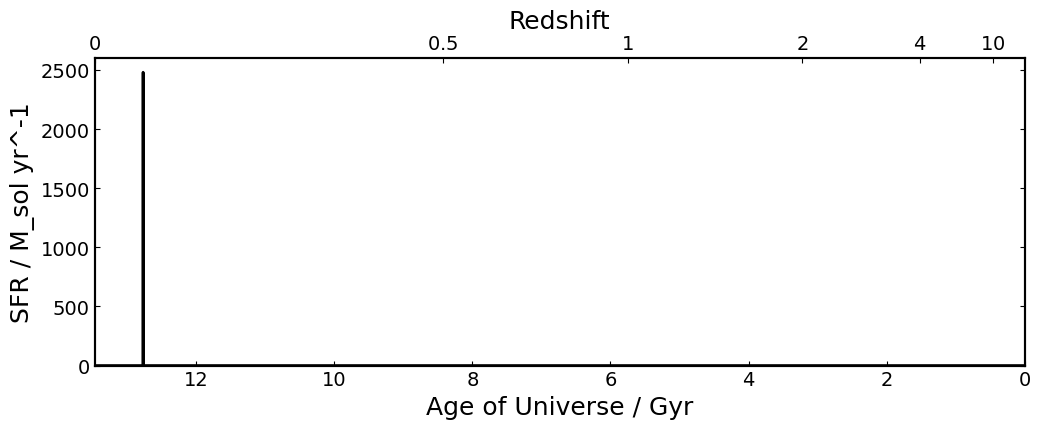

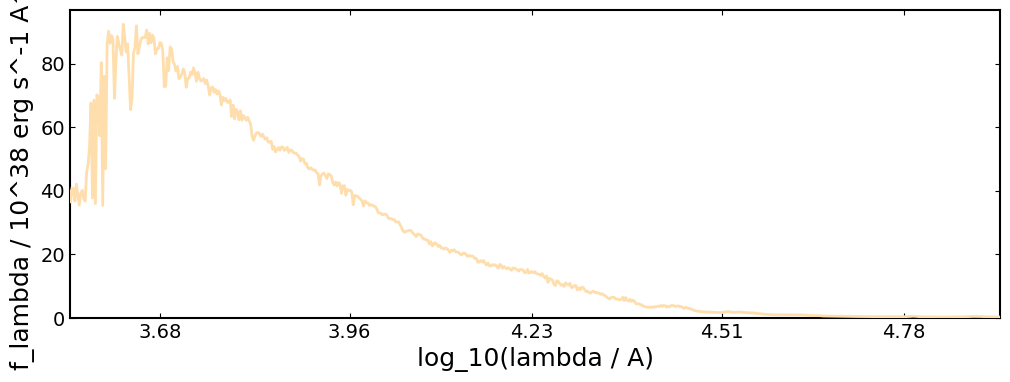

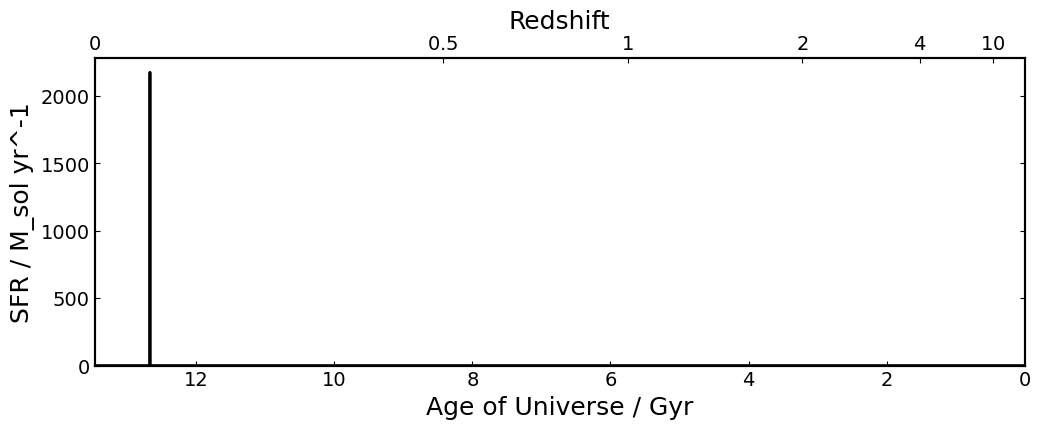

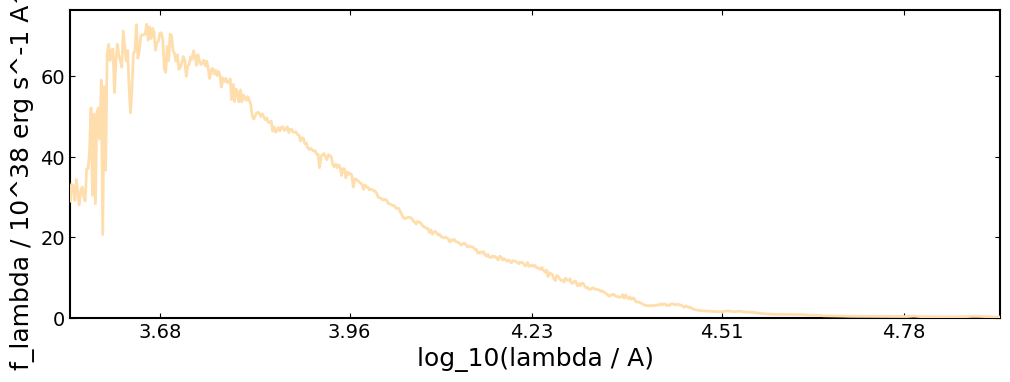

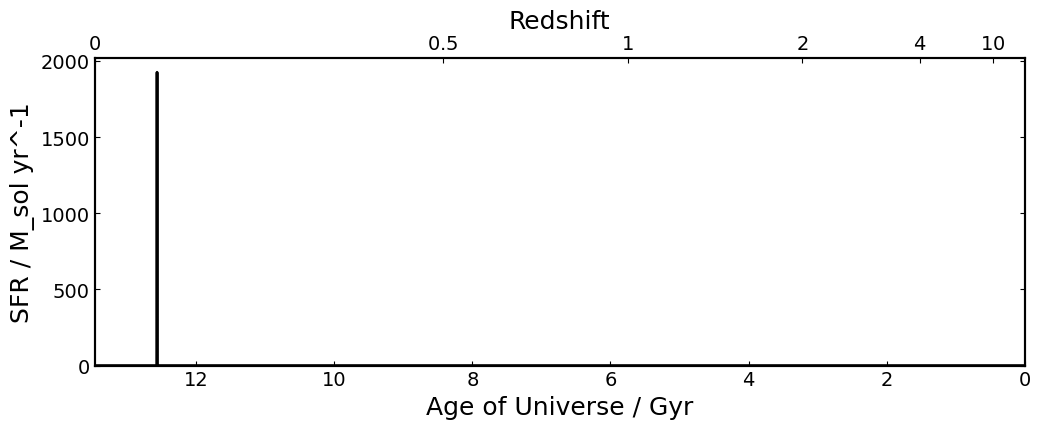

In [ ]:
#with SFH plots (delta functions)
for age in ages_gyr:

    burst = {
        "age": age,            # Gyr before observation
        "massformed": 10,     # log10(M*/Msun)
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list, spec_units='mujy', phot_units='mujy'
    )

    # Plot spectrum
    fig1 = model.plot()

    # Plot SFH (delta function)
    fig2 = model.sfh.plot()

    plt.show()


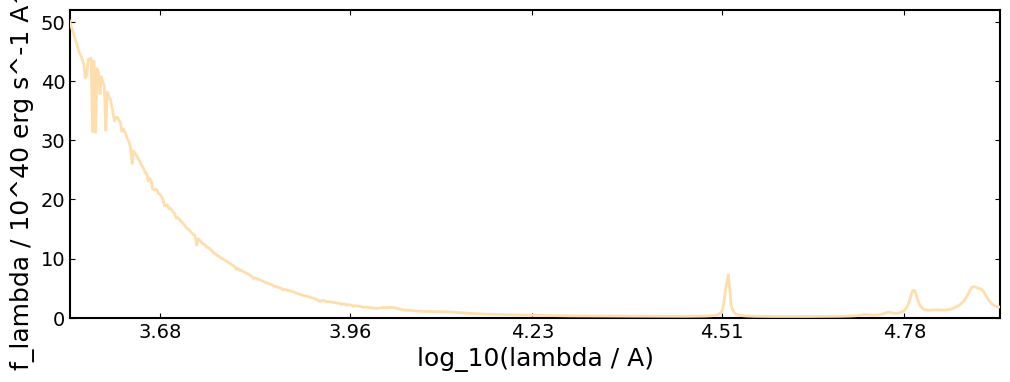

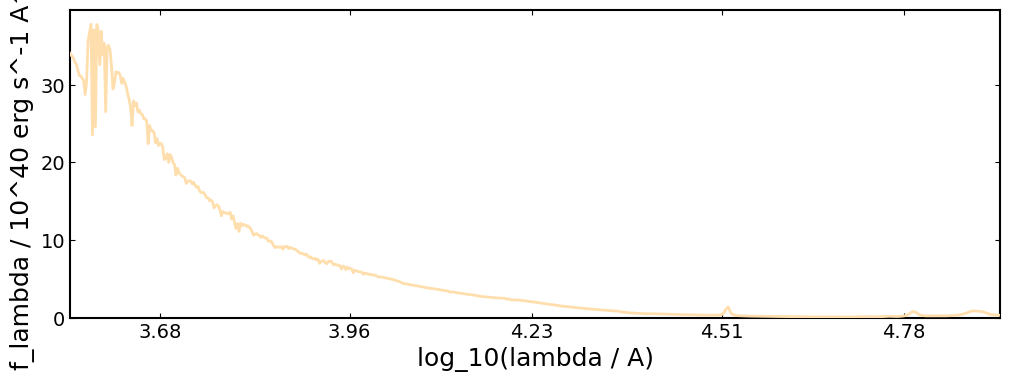

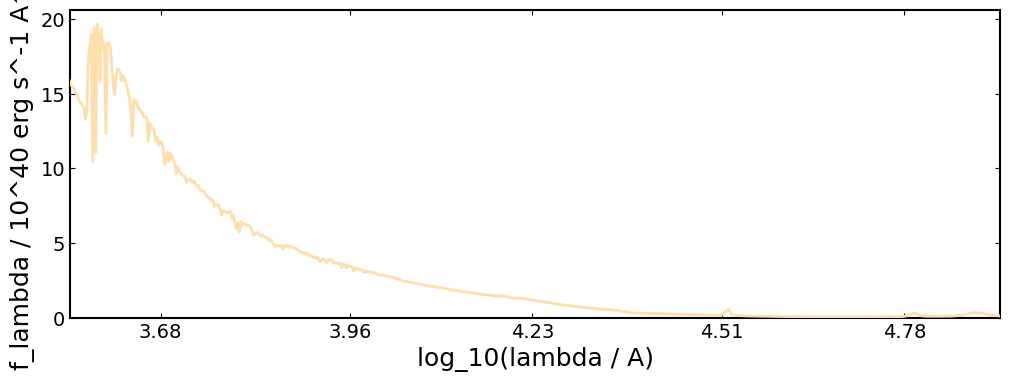

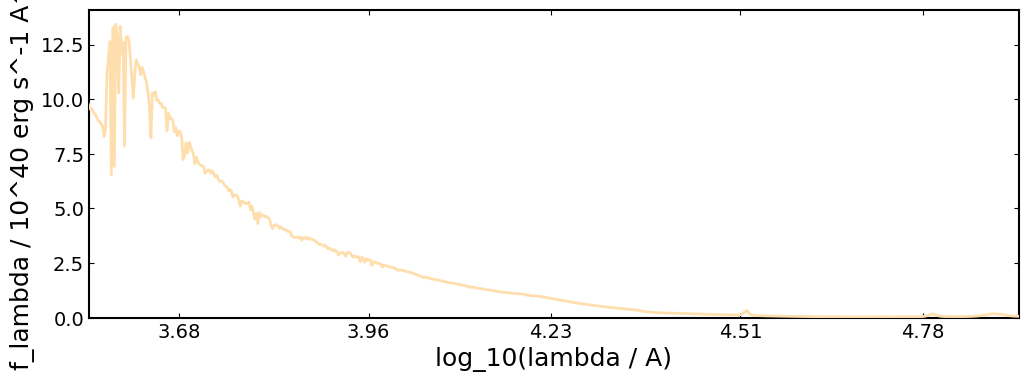

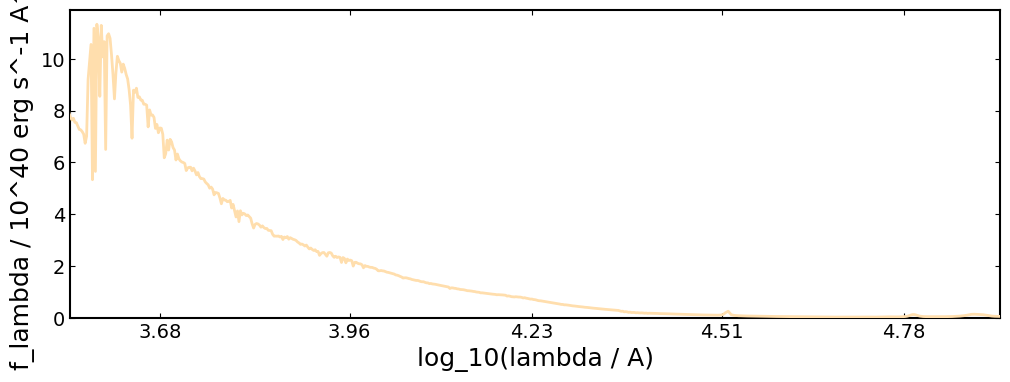

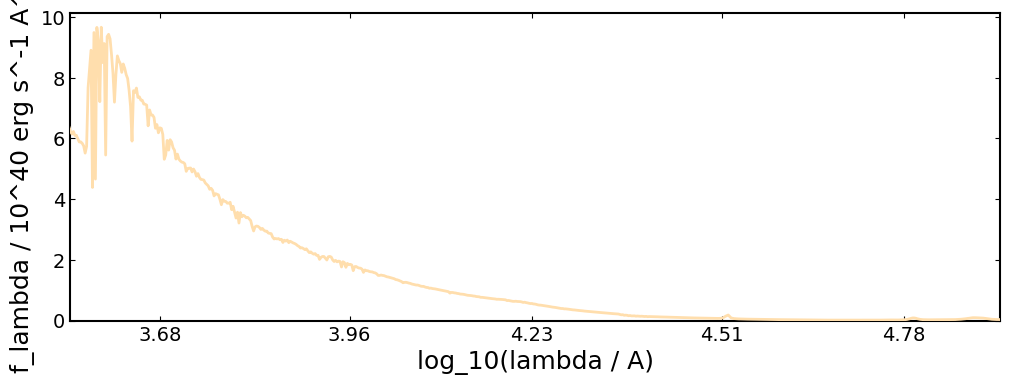

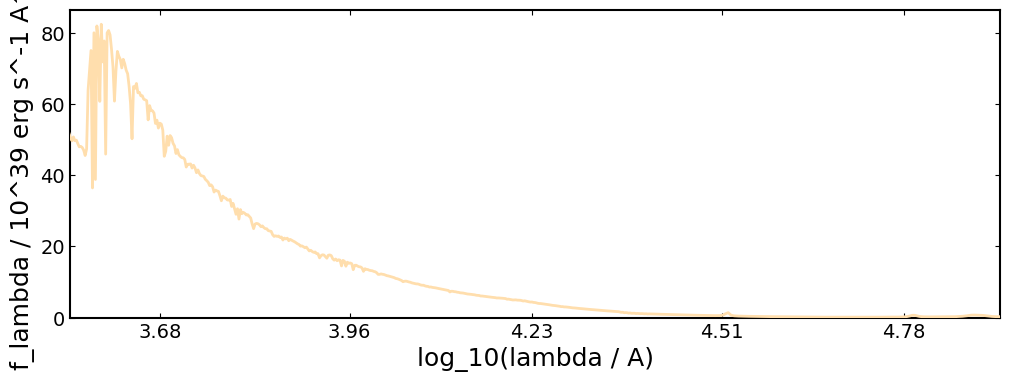

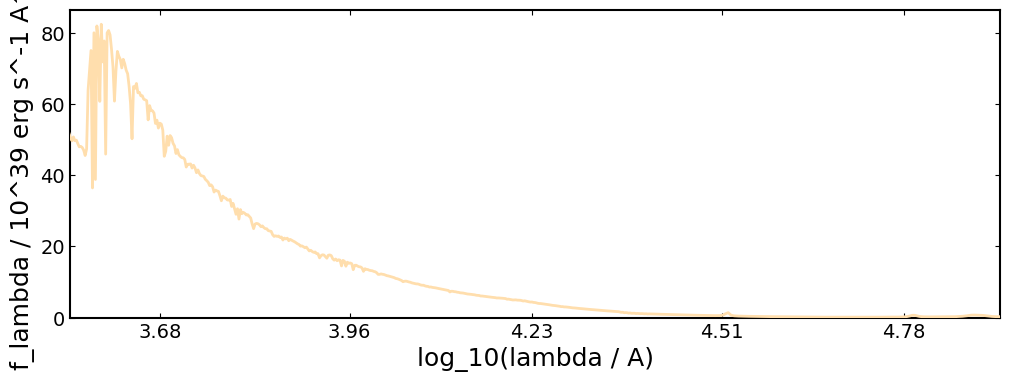

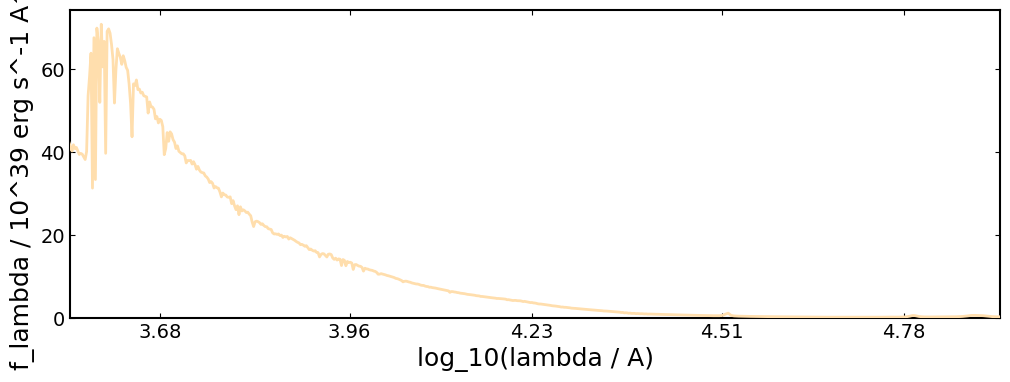

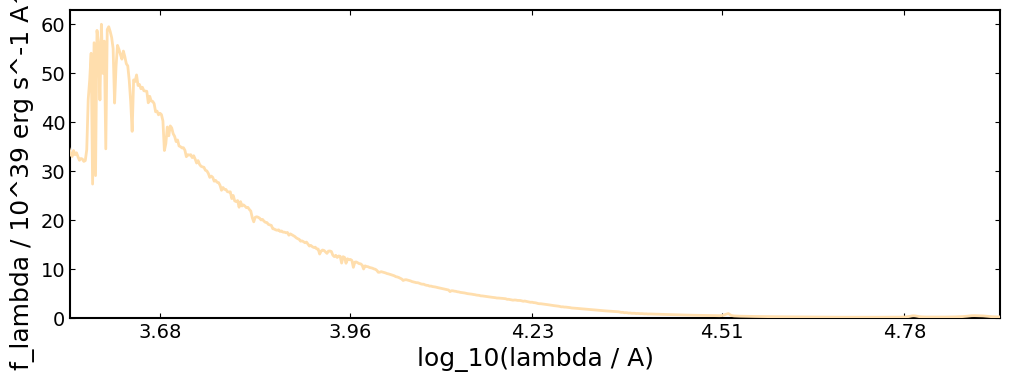

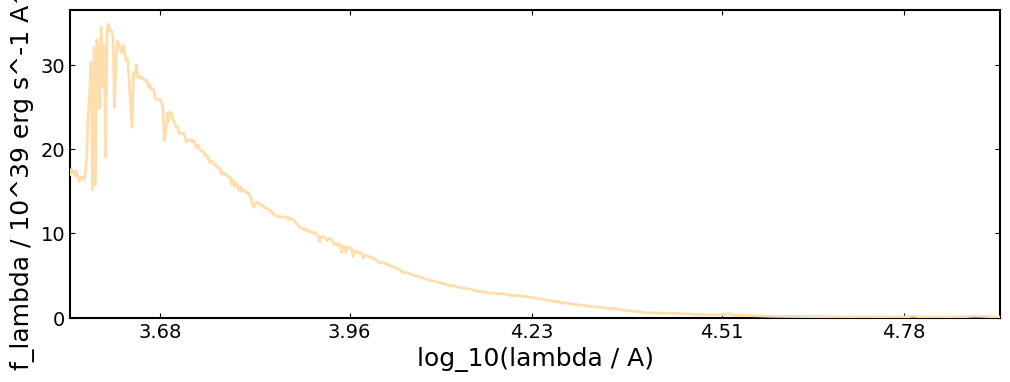

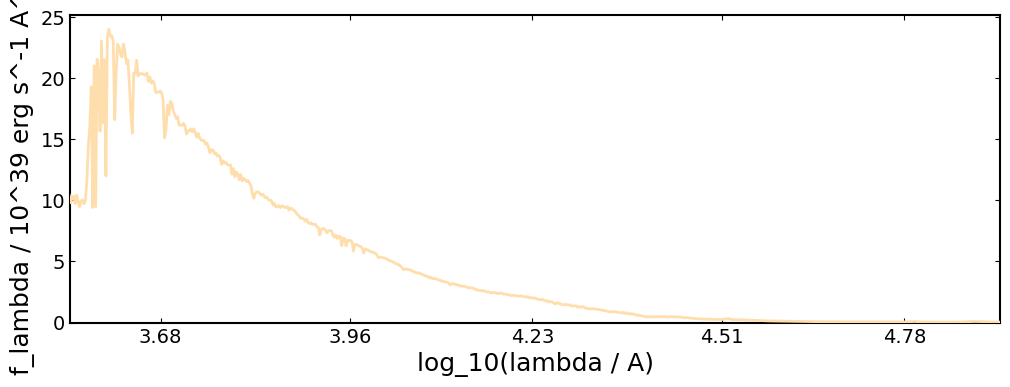

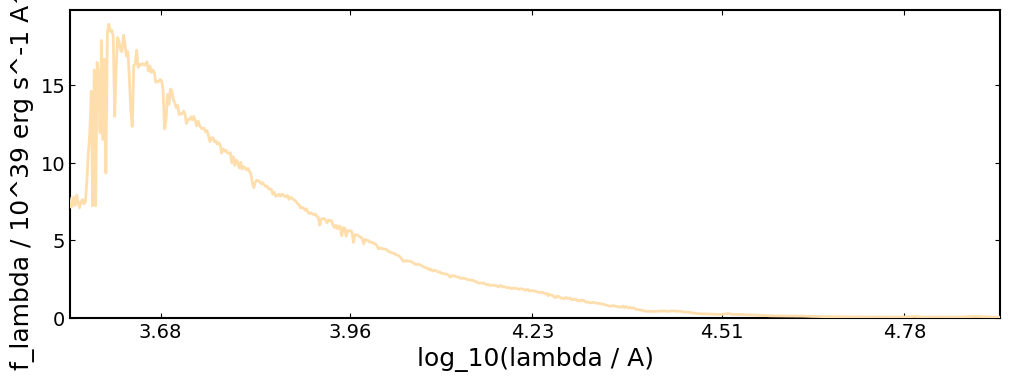

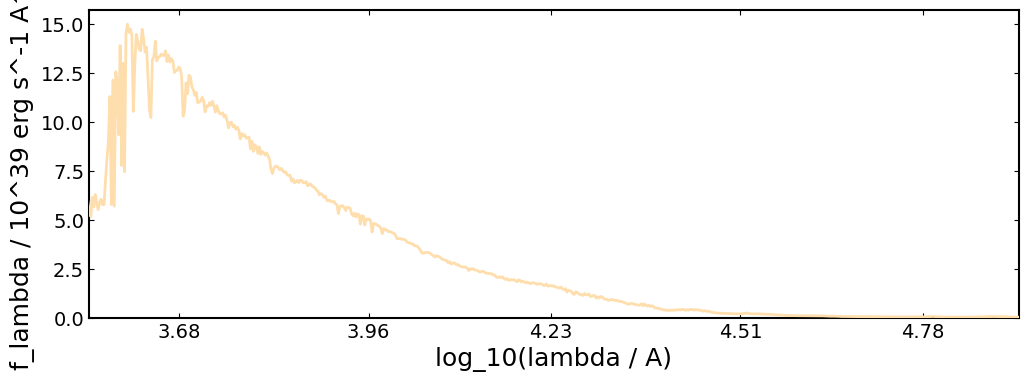

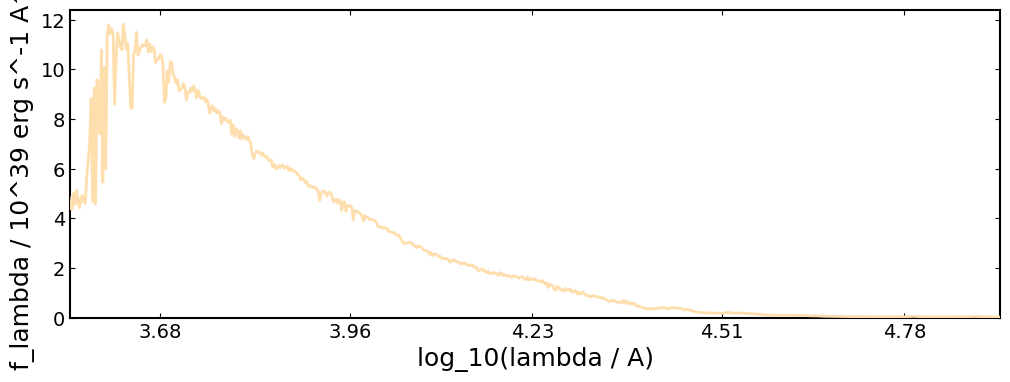

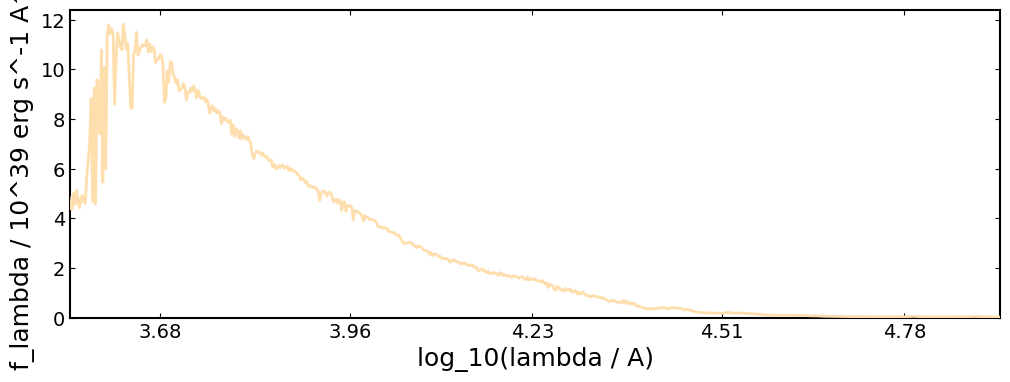

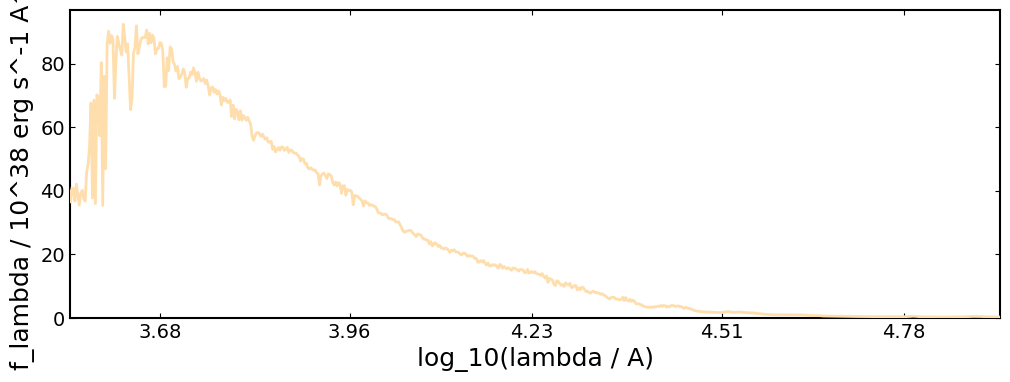

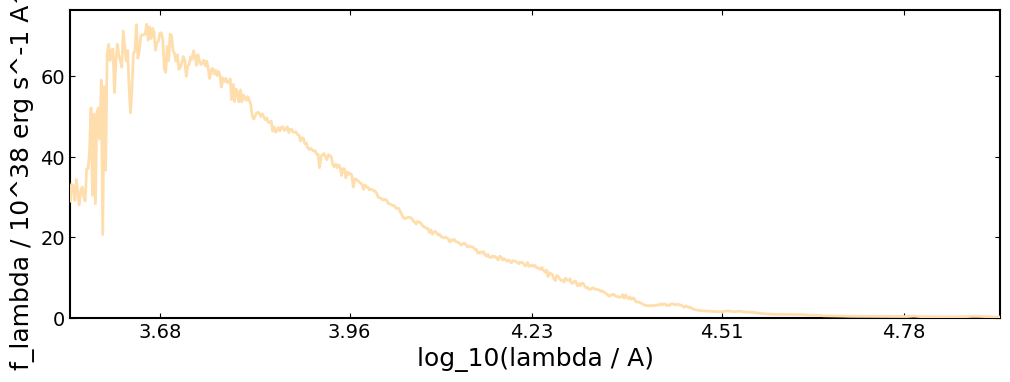

In [17]:
#without SFH plots (delta functions)
for age in ages_gyr:

    burst = {
        "age": age,            # Gyr before observation
        "massformed": 10,     # log10(M*/Msun)
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list, spec_units='mujy', phot_units='mujy'
    )

    fig = model.plot()

    plt.show()

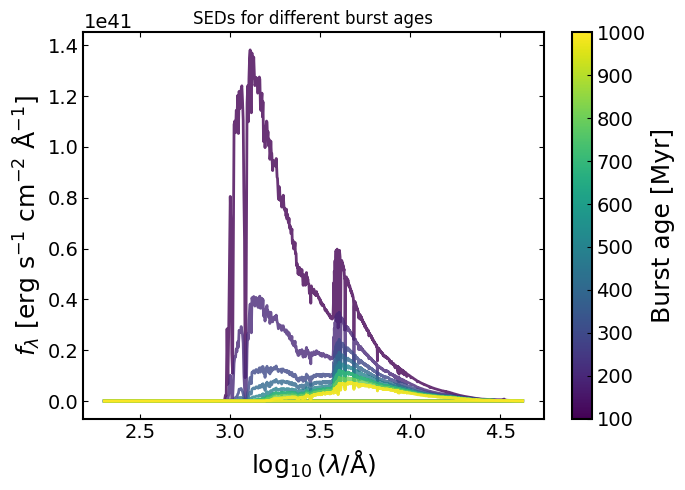

In [29]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    #np.arange(0, 100, 10)
    np.arange(100, 1001, 100)
])

# Dust & model
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}

# Filters
base = (
    r"D:/Users/Abigail Crowther/Desktop/Uni/Year 4/MPhys Projects/"
    r"Semester 2 - Star Formation Histories/star-formation-histories/bagpipes/examples"
)

rel_filters = np.loadtxt(base + "/filters/goodss_filt_list.txt", dtype="str")
goodss_filt_list = [base + "/" + f for f in rel_filters]


# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Create the model galaxy, get spectrum in erg s^-1 cm^-2 A^-1 (default)
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(200., 42000., 10.)
    )

    ax.plot(
        np.log10(model.spec_wavs),  # log10(lambda / Å)
        model.spectrum,             # f_lambda [erg s^-1 cm^-2 Å^-1]
        color=cmap(norm(t)),
        alpha=0.8
    )

# Labels & title
ax.set_xlabel(r"$\log_{10}(\lambda / \mathrm{\AA})$")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()